# NB01 — Sample Design and Omics-Layer Inventory

**Project**: Harvard Forest long-term warming, DNA vs RNA functional response
**Study**: `nmdc:sty-11-8ws97026` (Blanchard, Barre Woods)

## Goal
Build the canonical sample × treatment × horizon × incubation table from `nmdc_metadata.biosample_set` and confirm which biosamples have data in each omics layer (metagenome, metatranscriptome, MAGs, kraken2, metabolite IDs).

In [1]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# On BERDL JupyterHub, spark is injected via get_spark_session()
spark = get_spark_session()

STUDY_ID = 'nmdc:sty-11-8ws97026'
OUT_DIR = os.path.abspath('../data')
FIG_DIR = os.path.abspath('../figures')
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
print(f'Output dirs: data={OUT_DIR}, figures={FIG_DIR}')

Output dirs: data=/home/cmungall/BERIL-research-observatory/projects/harvard_forest_warming/data, figures=/home/cmungall/BERIL-research-observatory/projects/harvard_forest_warming/figures


## 1. Study record

In [2]:
study = spark.sql(f'''
    SELECT id, name, principal_investigator_name,
           principal_investigator_orcid, type
    FROM nmdc_metadata.study_set
    WHERE id = '{STUDY_ID}'
''').toPandas()
study

,id,name,principal_investigator_name,principal_investigator_orcid,type
0,nmdc:sty-11-8ws97026,Molecular mechanisms underlying changes in the...,Jeffrey Blanchard,0000-0002-7310-9678,nmdc:Study


## 2. Biosamples and their treatment / horizon / incubation labels

Treatment, horizon, and incubation labels come from the biosample `name` field plus `env_medium_has_raw_value`:
- `BW-C-*` / `BW-H-*` → control vs heated
- `-O` / `-M` → organic vs mineral horizon
- `Inc-*` → lab incubation

In [3]:
biosamples = spark.sql(f'''
    SELECT b.id as biosample_id, b.name as sample_name,
           b.env_medium_has_raw_value as env_medium,
           b.env_local_scale_has_raw_value as env_local_scale,
           b.env_broad_scale_has_raw_value as env_broad_scale,
           b.depth_has_raw_value as depth_raw,
           b.collection_date_has_raw_value as collection_date,
           b.geo_loc_name_has_raw_value as geo_loc,
           b.lat_lon_has_raw_value as lat_lon,
           b.elev as elevation_m
    FROM nmdc_metadata.biosample_set b
    JOIN nmdc_metadata.biosample_set_associated_studies s ON b.id = s.parent_id
    WHERE s.associated_studies = '{STUDY_ID}'
    ORDER BY b.name
''').toPandas()

def parse_design(name):
    incubated = name.startswith('Inc-')
    body = name[len('Inc-'):] if incubated else name
    # Pattern: BW-{C|H}-<plot>-{O|M}
    m = re.match(r'^BW-(C|H)-(\d+)-(O|M)$', body)
    if not m:
        return pd.Series([np.nan, np.nan, np.nan, incubated],
                         index=['treatment', 'plot', 'horizon', 'incubated'])
    treatment = 'heated' if m.group(1) == 'H' else 'control'
    plot = int(m.group(2))
    horizon = 'organic' if m.group(3) == 'O' else 'mineral'
    return pd.Series([treatment, plot, horizon, incubated],
                     index=['treatment', 'plot', 'horizon', 'incubated'])

design = biosamples.join(biosamples['sample_name'].apply(parse_design))
print(f'Biosamples: {len(design)}')
print(f'Unparsed: {design["treatment"].isna().sum()}')
design.head(10)

Biosamples: 42
Unparsed: 0


,biosample_id,sample_name,env_medium,env_local_scale,env_broad_scale,depth_raw,collection_date,geo_loc,lat_lon,elevation_m,treatment,plot,horizon,incubated
0,nmdc:bsm-11-622k6044,BW-C-12-M,forest soil [ENVO:00002261],mineral horizon [ENVO:03600011],forest biome [ENVO:01000174],.02 -.10,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,control,12,mineral,False
1,nmdc:bsm-11-pwa2h444,BW-C-12-O,forest soil [ENVO:00002261],organic horizon [ENVO:03600018],forest biome [ENVO:01000174],0 - .02,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,control,12,organic,False
2,nmdc:bsm-11-frgt4x11,BW-C-14-M,forest soil [ENVO:00002261],mineral horizon [ENVO:03600011],forest biome [ENVO:01000174],.02 -.10,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,control,14,mineral,False
3,nmdc:bsm-11-4rx1wt74,BW-C-14-O,forest soil [ENVO:00002261],organic horizon [ENVO:03600018],forest biome [ENVO:01000174],0 - .02,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,control,14,organic,False
4,nmdc:bsm-11-93mc8g67,BW-C-19-M,forest soil [ENVO:00002261],mineral horizon [ENVO:03600011],forest biome [ENVO:01000174],.02 -.10,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,control,19,mineral,False
5,nmdc:bsm-11-whgy3b08,BW-C-19-O,forest soil [ENVO:00002261],organic horizon [ENVO:03600018],forest biome [ENVO:01000174],0 - .02,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,control,19,organic,False
6,nmdc:bsm-11-g61cvw79,BW-C-27-M,forest soil [ENVO:00002261],mineral horizon [ENVO:03600011],forest biome [ENVO:01000174],.02 -.10,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,control,27,mineral,False
7,nmdc:bsm-11-m7z9y338,BW-C-27-O,forest soil [ENVO:00002261],organic horizon [ENVO:03600018],forest biome [ENVO:01000174],0 - .02,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,control,27,organic,False
8,nmdc:bsm-11-cpekyy11,BW-C-30-M,forest soil [ENVO:00002261],mineral horizon [ENVO:03600011],forest biome [ENVO:01000174],.02 -.10,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,control,30,mineral,False
9,nmdc:bsm-11-3n3k2m62,BW-C-30-O,forest soil [ENVO:00002261],organic horizon [ENVO:03600018],forest biome [ENVO:01000174],0 - .02,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,control,30,organic,False


In [4]:
# Cross-tab the design
print('Treatment x Horizon x Incubation:')
print(pd.crosstab([design['treatment'], design['horizon']], design['incubated'],
                  margins=True, margins_name='Total'))

# Confirm sanity vs env_medium label
print('\nenv_medium vs parsed treatment:')
print(pd.crosstab(design['env_medium'], design['treatment']))

Treatment x Horizon x Incubation:
incubated          False  True  Total
treatment horizon                    
control   mineral      7     0      7
          organic      7     7     14
heated    mineral      7     0      7
          organic      7     7     14
Total                 28    14     42

env_medium vs parsed treatment:
treatment                           control  heated
env_medium                                         
forest soil [ENVO:00002261]              21       0
heat stressed soil [ENVO:00005781]        0      21


## 3. Workflow runs per sample per omics layer

In [5]:
wf = spark.sql(f'''
    SELECT bw.biosample_id, bw.workflow_run_id, w.type as workflow_type
    FROM nmdc_metadata.biosample_to_workflow_run bw
    JOIN nmdc_metadata.workflow_execution_set w ON bw.workflow_run_id = w.id
    WHERE bw.biosample_id IN (
        SELECT parent_id FROM nmdc_metadata.biosample_set_associated_studies
        WHERE associated_studies = '{STUDY_ID}'
    )
''').toPandas()
print(f'Workflow runs: {len(wf)}')
print('Counts by workflow type:')
print(wf['workflow_type'].value_counts())

Workflow runs: 477
Counts by workflow type:
workflow_type
nmdc:NomAnalysis                            77
nmdc:ReadQcAnalysis                         71
nmdc:MetabolomicsAnalysis                   66
nmdc:MetatranscriptomeAnnotation            39
nmdc:MetatranscriptomeAssembly              39
nmdc:MetatranscriptomeExpressionAnalysis    39
nmdc:MetaproteomicsAnalysis                 34
nmdc:MetagenomeAnnotation                   28
nmdc:MetagenomeAssembly                     28
nmdc:ReadBasedTaxonomyAnalysis              28
nmdc:MagsAnalysis                           28
Name: count, dtype: int64


In [6]:
# Per-sample omics-layer presence matrix
OMICS_LAYERS = [
    'nmdc:ReadQcAnalysis',
    'nmdc:MetagenomeAssembly',
    'nmdc:MetagenomeAnnotation',
    'nmdc:ReadBasedTaxonomyAnalysis',
    'nmdc:MagsAnalysis',
    'nmdc:MetatranscriptomeAssembly',
    'nmdc:MetatranscriptomeAnnotation',
    'nmdc:MetatranscriptomeExpressionAnalysis',
    'nmdc:MetabolomicsAnalysis',
    'nmdc:MetaproteomicsAnalysis',
    'nmdc:NomAnalysis',
]

presence = (wf.groupby(['biosample_id', 'workflow_type']).size().unstack(fill_value=0) > 0).astype(int)
presence = presence.reindex(columns=[c for c in OMICS_LAYERS if c in presence.columns], fill_value=0)
presence.index.name = 'biosample_id'

design_with_presence = design.merge(presence.reset_index(), on='biosample_id', how='left').fillna(0)
for c in OMICS_LAYERS:
    if c in design_with_presence.columns:
        design_with_presence[c] = design_with_presence[c].astype(int)
design_with_presence.head(10)

,biosample_id,sample_name,env_medium,env_local_scale,env_broad_scale,depth_raw,collection_date,geo_loc,lat_lon,elevation_m,...,nmdc:MetagenomeAssembly,nmdc:MetagenomeAnnotation,nmdc:ReadBasedTaxonomyAnalysis,nmdc:MagsAnalysis,nmdc:MetatranscriptomeAssembly,nmdc:MetatranscriptomeAnnotation,nmdc:MetatranscriptomeExpressionAnalysis,nmdc:MetabolomicsAnalysis,nmdc:MetaproteomicsAnalysis,nmdc:NomAnalysis
0,nmdc:bsm-11-622k6044,BW-C-12-M,forest soil [ENVO:00002261],mineral horizon [ENVO:03600011],forest biome [ENVO:01000174],.02 -.10,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,...,1,1,1,1,1,1,1,1,1,1
1,nmdc:bsm-11-pwa2h444,BW-C-12-O,forest soil [ENVO:00002261],organic horizon [ENVO:03600018],forest biome [ENVO:01000174],0 - .02,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,...,0,0,0,0,1,1,1,1,1,0
2,nmdc:bsm-11-frgt4x11,BW-C-14-M,forest soil [ENVO:00002261],mineral horizon [ENVO:03600011],forest biome [ENVO:01000174],.02 -.10,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,...,1,1,1,1,1,1,1,1,1,1
3,nmdc:bsm-11-4rx1wt74,BW-C-14-O,forest soil [ENVO:00002261],organic horizon [ENVO:03600018],forest biome [ENVO:01000174],0 - .02,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,...,0,0,0,0,1,1,1,1,1,0
4,nmdc:bsm-11-93mc8g67,BW-C-19-M,forest soil [ENVO:00002261],mineral horizon [ENVO:03600011],forest biome [ENVO:01000174],.02 -.10,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,...,1,1,1,1,1,1,1,1,1,1
5,nmdc:bsm-11-whgy3b08,BW-C-19-O,forest soil [ENVO:00002261],organic horizon [ENVO:03600018],forest biome [ENVO:01000174],0 - .02,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,...,0,0,0,0,1,1,1,1,1,0
6,nmdc:bsm-11-g61cvw79,BW-C-27-M,forest soil [ENVO:00002261],mineral horizon [ENVO:03600011],forest biome [ENVO:01000174],.02 -.10,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,...,1,1,1,1,1,1,1,0,0,0
7,nmdc:bsm-11-m7z9y338,BW-C-27-O,forest soil [ENVO:00002261],organic horizon [ENVO:03600018],forest biome [ENVO:01000174],0 - .02,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,...,0,0,0,0,1,1,1,1,1,0
8,nmdc:bsm-11-cpekyy11,BW-C-30-M,forest soil [ENVO:00002261],mineral horizon [ENVO:03600011],forest biome [ENVO:01000174],.02 -.10,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,...,1,1,1,1,0,0,0,1,1,1
9,nmdc:bsm-11-3n3k2m62,BW-C-30-O,forest soil [ENVO:00002261],organic horizon [ENVO:03600018],forest biome [ENVO:01000174],0 - .02,2017-05-24,"USA: Massachusetts, Petersham",42.481016 -72.178343,302.0,...,0,0,0,0,1,1,1,0,0,0


In [7]:
# Coverage by treatment x horizon x incubation
key_layers = [
    'nmdc:MetagenomeAnnotation',
    'nmdc:MetatranscriptomeAnnotation',
    'nmdc:ReadBasedTaxonomyAnalysis',
    'nmdc:MagsAnalysis',
    'nmdc:MetabolomicsAnalysis',
]
for lay in key_layers:
    if lay in design_with_presence.columns:
        coverage = (design_with_presence.groupby(['treatment', 'horizon', 'incubated'])[lay]
                    .sum().reset_index())
        print(f'\n{lay}:')
        print(coverage.pivot_table(index=['treatment', 'horizon'], columns='incubated', values=lay, fill_value=0))


nmdc:MetagenomeAnnotation:
incubated          False  True 
treatment horizon              
control   mineral    7.0    0.0
          organic    0.0    7.0
heated    mineral    7.0    0.0
          organic    0.0    7.0

nmdc:MetatranscriptomeAnnotation:
incubated          False  True 
treatment horizon              
control   mineral    5.0    0.0
          organic    7.0    7.0
heated    mineral    6.0    0.0
          organic    7.0    7.0

nmdc:ReadBasedTaxonomyAnalysis:
incubated          False  True 
treatment horizon              
control   mineral    7.0    0.0
          organic    0.0    7.0
heated    mineral    7.0    0.0
          organic    0.0    7.0

nmdc:MagsAnalysis:
incubated          False  True 
treatment horizon              
control   mineral    7.0    0.0
          organic    0.0    7.0
heated    mineral    7.0    0.0
          organic    0.0    7.0

nmdc:MetabolomicsAnalysis:
incubated          False  True 
treatment horizon              
control   mineral    6.0

## 4. Save outputs

In [8]:
# Sample design + omics presence
out_design = os.path.join(OUT_DIR, 'sample_design.tsv')
design_with_presence.to_csv(out_design, sep='\t', index=False)
print(f'Wrote {out_design}: {len(design_with_presence)} rows')

# Workflow run table (reusable in NB02)
out_wf = os.path.join(OUT_DIR, 'workflow_runs.tsv')
wf.to_csv(out_wf, sep='\t', index=False)
print(f'Wrote {out_wf}: {len(wf)} rows')

Wrote /home/cmungall/BERIL-research-observatory/projects/harvard_forest_warming/data/sample_design.tsv: 42 rows
Wrote /home/cmungall/BERIL-research-observatory/projects/harvard_forest_warming/data/workflow_runs.tsv: 477 rows


## 5. Design figure

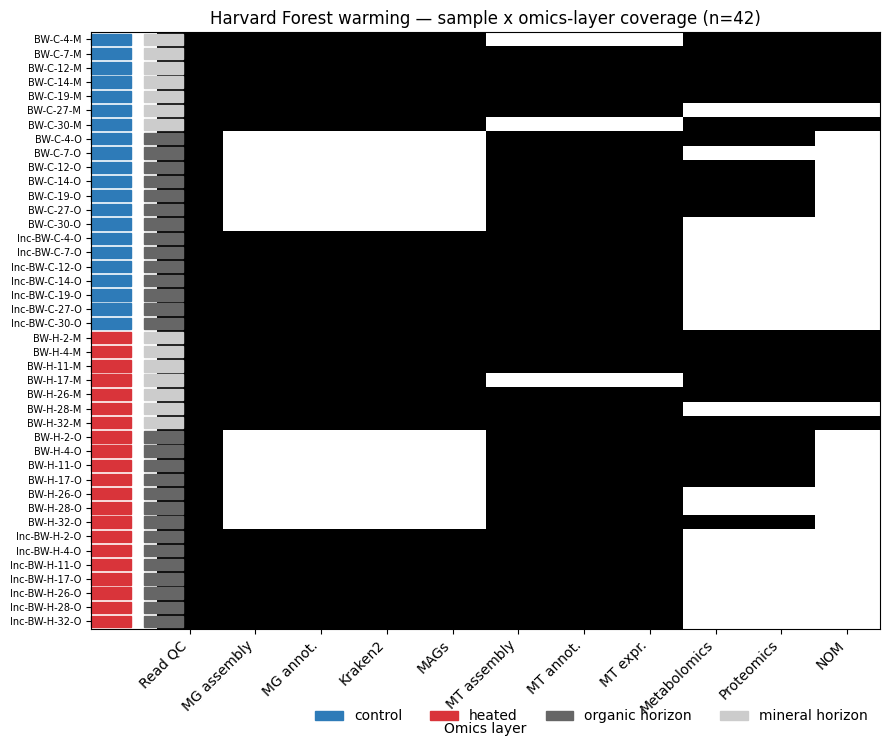

Wrote /home/cmungall/BERIL-research-observatory/projects/harvard_forest_warming/figures/01_design.png


In [9]:
# Heatmap: rows = samples (sorted), columns = omics layers, cells = 0/1
label_map = {
    'nmdc:ReadQcAnalysis': 'Read QC',
    'nmdc:MetagenomeAssembly': 'MG assembly',
    'nmdc:MetagenomeAnnotation': 'MG annot.',
    'nmdc:ReadBasedTaxonomyAnalysis': 'Kraken2',
    'nmdc:MagsAnalysis': 'MAGs',
    'nmdc:MetatranscriptomeAssembly': 'MT assembly',
    'nmdc:MetatranscriptomeAnnotation': 'MT annot.',
    'nmdc:MetatranscriptomeExpressionAnalysis': 'MT expr.',
    'nmdc:MetabolomicsAnalysis': 'Metabolomics',
    'nmdc:MetaproteomicsAnalysis': 'Proteomics',
    'nmdc:NomAnalysis': 'NOM',
}

# Sort by treatment, horizon, incubated, plot
ordered = design_with_presence.sort_values(['treatment', 'horizon', 'incubated', 'plot'])
layer_cols = [c for c in OMICS_LAYERS if c in ordered.columns]
M = ordered[layer_cols].values

fig, ax = plt.subplots(figsize=(9, max(6, 0.18 * len(ordered))))
ax.imshow(M, aspect='auto', cmap='Greys', vmin=0, vmax=1, interpolation='nearest')
ax.set_xticks(range(len(layer_cols)))
ax.set_xticklabels([label_map.get(c, c) for c in layer_cols], rotation=45, ha='right')
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels([f"{r['sample_name']}" for _, r in ordered.iterrows()], fontsize=7)
ax.set_xlabel('Omics layer')
ax.set_title(f'Harvard Forest warming — sample x omics-layer coverage (n={len(ordered)})')

# Color bar at left for treatment
treat_color = ordered['treatment'].map({'control': '#2e7bb8', 'heated': '#d9343a'})
horizon_marker = ordered['horizon'].map({'organic': 'o', 'mineral': 's'})
for i, (_, r) in enumerate(ordered.iterrows()):
    ax.add_patch(plt.Rectangle((-1.5, i - 0.4), 0.6, 0.8,
                                color=treat_color.iloc[i], clip_on=False))
    ax.add_patch(plt.Rectangle((-0.7, i - 0.4), 0.6, 0.8,
                                color='#666666' if r['horizon'] == 'organic' else '#cccccc',
                                clip_on=False))
ax.set_xlim(-1.5, len(layer_cols) - 0.5)

# Legend handles
from matplotlib.patches import Patch
handles = [
    Patch(color='#2e7bb8', label='control'),
    Patch(color='#d9343a', label='heated'),
    Patch(color='#666666', label='organic horizon'),
    Patch(color='#cccccc', label='mineral horizon'),
]
ax.legend(handles=handles, loc='lower right', bbox_to_anchor=(1.0, -0.18), ncol=4, frameon=False)

plt.tight_layout()
out_fig = os.path.join(FIG_DIR, '01_design.png')
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Wrote {out_fig}')

## 6. Summary

- 42 biosamples successfully parsed into a 4-factor design (treatment × horizon × incubated × plot).
- All samples are from a single date (2017-05-24) and a single site (Petersham, MA).
- Each sample carries multiple omics layers; metagenome and metatranscriptome annotation coverage is the primary basis for H1 and H2 tests.
- Design table and workflow-run table written to `../data/` for reuse in downstream notebooks.